# Análisis de Correlación: Parque Vehicular vs. PM2.5 en Guatemala (2022-2024)
## Metodología CRISP-DM

**Objetivo:** Cuantificar la relación entre el crecimiento del parque vehicular liviano y los niveles de contaminación por partículas PM2.5 en Guatemala.

**Autor:** Senior Data Scientist - Análisis Ambiental y Movilidad Urbana  
**Periodo:** 2022-2024  
**Metodología:** CRISP-DM (Cross-Industry Standard Process for Data Mining)

---
## Fase 1: Comprensión del Negocio (Business Understanding)

### Contexto
Guatemala enfrenta desafíos de calidad del aire, particularmente con PM2.5 (partículas menores a 2.5 μm). El parque vehicular ha experimentado crecimiento sostenido en la última década.

### Preguntas de Negocio
1. ¿Existe correlación estadísticamente significativa entre el crecimiento vehicular y los niveles de PM2.5?
2. ¿Qué tipo de vehículos (motos, pickups, automóviles) tienen mayor impacto?
3. ¿El impacto marginal de cada vehículo adicional es cuantificable?
4. ¿La estacionalidad (época seca nov-may) enmascara la relación?

### Hipótesis
**H₀:** No existe relación lineal entre cantidad de vehículos registrados y concentración de PM2.5  
**H₁:** Existe una relación positiva significativa (β₁ > 0) donde PM2.5ₜ = β₀ + β₁(Vehículosₜ) + ε

### Consideraciones Académicas
- Datos de vehículos son de "Alza" (nuevos registros mensuales) → mide **impacto marginal incremental**
- PM2.5 en Guatemala presenta fuerte estacionalidad: ↑ en época seca (nov-may) independiente del parque vehicular
- Picos de importación generalmente a fin de año → potencial confusión temporal

In [1]:
# Importación de librerías
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import warnings
warnings.filterwarnings('ignore')

# Configuración de visualizaciones
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
%matplotlib inline

# Configuración de pandas para mejor visualización
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.float_format', '{:.2f}'.format)

print("✓ Librerías importadas correctamente")
print(f"Pandas version: {pd.__version__}")
print(f"NumPy version: {np.__version__}")

✓ Librerías importadas correctamente
Pandas version: 3.0.2
NumPy version: 2.4.4


---
## Fase 2: Comprensión de los Datos (Data Understanding)

### Carga de Datasets

In [2]:
# NOTA: Ajustar las rutas según la ubicación de los archivos
# Ejemplo: './data/INE_PARQUE_VEHICULAR_2022_2024.csv'

# Cargar datos de vehículos (INE)
try:
    df_vehiculos = pd.read_csv('Data/INE_PARQUE_VEHICULAR_2022_2024.csv')
    print("✓ Dataset de vehículos cargado exitosamente")
    print(f"Dimensiones: {df_vehiculos.shape}")
except FileNotFoundError:
    print("⚠ ERROR: Archivo de vehículos no encontrado. Verifica la ruta.")
    df_vehiculos = None

✓ Dataset de vehículos cargado exitosamente
Dimensiones: (78255, 9)


In [3]:
# Cargar datos de calidad del aire (PM2.5)
try:
    df_pm25 = pd.read_csv('Data/PM25-DATA-2022-2024.csv')
    print("✓ Dataset de PM2.5 cargado exitosamente")
    print(f"Dimensiones: {df_pm25.shape}")
    print(f"Frecuencia aproximada: {df_pm25.shape[0]} registros / {(df_pm25.shape[0] / (365*3*288)):.1f}x esperado (cada 5 min)")
except FileNotFoundError:
    print("⚠ ERROR: Archivo de PM2.5 no encontrado. Verifica la ruta.")
    df_pm25 = None

✓ Dataset de PM2.5 cargado exitosamente
Dimensiones: (275170, 2)
Frecuencia aproximada: 275170 registros / 0.9x esperado (cada 5 min)


### Análisis Exploratorio de Datos (EDA) - Vehículos

In [4]:
# Inspección inicial del dataset de vehículos
if df_vehiculos is not None:
    print("="*80)
    print("DATASET: PARQUE VEHICULAR (INE)")
    print("="*80)
    
    print("\n[1] Primeras 5 filas:")
    display(df_vehiculos.head())
    
    print("\n[2] Información general:")
    print(df_vehiculos.info())
    
    print("\n[3] Estadísticas descriptivas:")
    display(df_vehiculos.describe())
    
    print("\n[4] Valores nulos por columna:")
    print(df_vehiculos.isnull().sum())
    
    print("\n[5] Tipos de vehículos únicos:")
    if 'TIPO_VEHICULO' in df_vehiculos.columns:
        print(df_vehiculos['TIPO_VEHICULO'].value_counts())
    
    print("\n[6] Rango temporal:")
    if 'FECHA_ALZA' in df_vehiculos.columns:
        print(f"Desde: {df_vehiculos['FECHA_ALZA'].min()}")
        print(f"Hasta: {df_vehiculos['FECHA_ALZA'].max()}")

DATASET: PARQUE VEHICULAR (INE)

[1] Primeras 5 filas:


,FECHA_ALZA,NOMBRE_DEPARTAMENTO,NOMBRE_MUNICIPIO,MODELO_VEHICULO,LINEA_VEHICULO,TIPO_VEHICULO,USO_VEHICULO,MARCA_VEHICULO,CANTIDAD
0,2022/01,GUATEMALA,GUATEMALA,2010,FIT,AUTOMOVIL,PARTICULAR,HONDA,3
1,2022/01,GUATEMALA,GUATEMALA,2022,TAOS,CAMIONETA SPORT,PARTICULAR,VOLKSWAGEN,26
2,2022/02,GUATEMALA,GUATEMALA,2021,AVATAR LX,MOTO,MOTOCICLETA,FREEDOM,1
3,2022/01,GUATEMALA,GUATEMALA,2022,HILUX,PICK UP,PARTICULAR,TOYOTA,49
4,2022/01,GUATEMALA,GUATEMALA,2022,XR190L,MOTO,MOTOCICLETA,HONDA,8



[2] Información general:
<class 'pandas.DataFrame'>
RangeIndex: 78255 entries, 0 to 78254
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype
---  ------               --------------  -----
 0   FECHA_ALZA           78254 non-null  str  
 1   NOMBRE_DEPARTAMENTO  78254 non-null  str  
 2   NOMBRE_MUNICIPIO     78254 non-null  str  
 3   MODELO_VEHICULO      78254 non-null  str  
 4   LINEA_VEHICULO       78254 non-null  str  
 5   TIPO_VEHICULO        78254 non-null  str  
 6   USO_VEHICULO         78254 non-null  str  
 7   MARCA_VEHICULO       78254 non-null  str  
 8   CANTIDAD             78255 non-null  int64
dtypes: int64(1), str(8)
memory usage: 5.4 MB
None

[3] Estadísticas descriptivas:


,CANTIDAD
count,78255.00
mean,8.88
std,1241.95
min,1.00
25%,1.00
50%,1.00
75%,2.00
max,347357.00



[4] Valores nulos por columna:
FECHA_ALZA             1
NOMBRE_DEPARTAMENTO    1
NOMBRE_MUNICIPIO       1
MODELO_VEHICULO        1
LINEA_VEHICULO         1
TIPO_VEHICULO          1
USO_VEHICULO           1
MARCA_VEHICULO         1
CANTIDAD               0
dtype: int64

[5] Tipos de vehículos únicos:
TIPO_VEHICULO
CAMIONETA             32452
MOTO                  17082
AUTOMOVIL             16446
PICK UP                6870
MICROBUS               1563
CAMIONETILLA            867
PANEL                   776
CUATRIMOTO              654
TRIMOTO                 425
JEEP                    381
CAMIONETA SPORT         346
VEHICULO RUSTICO        274
CAMIONETA AGRICOLA       58
AMBULANCIA               43
LIMOSINA                  5
CARRO PARA GOLF           5
CARRO FUNEBRE             4
GO-KART                   2
CARRETILLA-AUTOM          1
Name: count, dtype: int64

[6] Rango temporal:
Desde: 2022/01
Hasta: 2024/12


### Análisis Exploratorio de Datos (EDA) - PM2.5

In [5]:
# Inspección inicial del dataset de PM2.5
if df_pm25 is not None:
    print("="*80)
    print("DATASET: CALIDAD DEL AIRE - PM2.5")
    print("="*80)
    
    print("\n[1] Primeras 5 filas:")
    display(df_pm25.head())
    
    print("\n[2] Información general:")
    print(df_pm25.info())
    
    print("\n[3] Valores nulos por columna:")
    print(df_pm25.isnull().sum())
    
    print("\n[4] Muestra de valores de Particulas_PM25 (primeros 10):")
    if 'Particulas_PM25' in df_pm25.columns:
        print(df_pm25['Particulas_PM25'].head(10).tolist())
    
    print("\n[5] Rango temporal:")
    if 'Time' in df_pm25.columns:
        print(f"Desde: {df_pm25['Time'].min()}")
        print(f"Hasta: {df_pm25['Time'].max()}")

DATASET: CALIDAD DEL AIRE - PM2.5

[1] Primeras 5 filas:


,Time,Particulas_PM25
0,2022-03-04 11:51:35,6 μg/m³
1,2022-03-04 11:56:35,3 μg/m³
2,2022-03-04 12:01:36,4 μg/m³
3,2022-03-04 12:06:36,4 μg/m³
4,2022-03-04 12:11:36,3 μg/m³



[2] Información general:
<class 'pandas.DataFrame'>
RangeIndex: 275170 entries, 0 to 275169
Data columns (total 2 columns):
 #   Column           Non-Null Count   Dtype
---  ------           --------------   -----
 0   Time             275170 non-null  str  
 1   Particulas_PM25  275170 non-null  str  
dtypes: str(2)
memory usage: 4.2 MB
None

[3] Valores nulos por columna:
Time               0
Particulas_PM25    0
dtype: int64

[4] Muestra de valores de Particulas_PM25 (primeros 10):
['6 μg/m³', '3 μg/m³', '4 μg/m³', '4 μg/m³', '3 μg/m³', '3 μg/m³', '4 μg/m³', '3 μg/m³', '4 μg/m³', '4 μg/m³']

[5] Rango temporal:
Desde: 2022-03-04 11:51:35
Hasta: 2024-12-31 23:55:00


---
## Fase 3: Preparación de Datos (Data Preparation)

Esta es la fase **crucial** del proyecto. Requiere:
1. Limpieza del string " μg/m³" en PM2.5
2. Conversión a datetime de ambas columnas temporales
3. Agregación temporal: 5 min → promedio mensual
4. Merge por Año-Mes

### 3.1 Limpieza de Dataset PM2.5

In [6]:
# Crear copia para preservar datos originales
if df_pm25 is not None:
    df_pm25_clean = df_pm25.copy()
    
    print("[PASO 1] Limpieza de columna Particulas_PM25")
    print("Formato original:", df_pm25_clean['Particulas_PM25'].iloc[0])
    
    # Extraer solo los dígitos y convertir a float
    # Usa regex para capturar números (incluyendo decimales)
    df_pm25_clean['valor_pm25'] = df_pm25_clean['Particulas_PM25'].str.extract(r'(\d+\.?\d*)').astype(float)
    
    print("Formato limpio:", df_pm25_clean['valor_pm25'].iloc[0])
    print(f"✓ Valores convertidos: {df_pm25_clean['valor_pm25'].notna().sum()} / {len(df_pm25_clean)}")
    print(f"⚠ Valores nulos generados: {df_pm25_clean['valor_pm25'].isna().sum()}")
    
    # Estadísticas rápidas para detectar outliers
    print("\nEstadísticas de PM2.5:")
    print(df_pm25_clean['valor_pm25'].describe())

[PASO 1] Limpieza de columna Particulas_PM25
Formato original: 6 μg/m³
Formato limpio: 6.0
✓ Valores convertidos: 275170 / 275170
⚠ Valores nulos generados: 0

Estadísticas de PM2.5:
count   275170.00
mean        33.00
std         49.13
min          0.00
25%          7.00
50%         16.00
75%         41.00
max       1928.00
Name: valor_pm25, dtype: float64


In [7]:
# Conversión de columna Time a datetime con manejo de excepciones
if df_pm25 is not None:
    print("[PASO 2] Conversión de Time a datetime")
    
    try:
        df_pm25_clean['timestamp'] = pd.to_datetime(df_pm25_clean['Time'], errors='coerce')
        
        # Verificar conversión exitosa
        conversiones_exitosas = df_pm25_clean['timestamp'].notna().sum()
        conversiones_fallidas = df_pm25_clean['timestamp'].isna().sum()
        
        print(f"✓ Conversiones exitosas: {conversiones_exitosas}")
        print(f"⚠ Conversiones fallidas: {conversiones_fallidas}")
        
        if conversiones_fallidas > 0:
            print("\nEjemplos de fechas problemáticas:")
            print(df_pm25_clean[df_pm25_clean['timestamp'].isna()]['Time'].head())
        
        # Eliminar filas con timestamp nulo
        df_pm25_clean = df_pm25_clean.dropna(subset=['timestamp'])
        
        print(f"\nRango temporal final:")
        print(f"Desde: {df_pm25_clean['timestamp'].min()}")
        print(f"Hasta: {df_pm25_clean['timestamp'].max()}")
        
    except Exception as e:
        print(f"⚠ ERROR en conversión de fechas: {e}")

[PASO 2] Conversión de Time a datetime
✓ Conversiones exitosas: 275170
⚠ Conversiones fallidas: 0

Rango temporal final:
Desde: 2022-03-04 11:51:35
Hasta: 2024-12-31 23:55:00


In [8]:
# Detección y tratamiento de outliers en PM2.5
if df_pm25 is not None:
    print("[PASO 3] Análisis y tratamiento de outliers")
    
    # Método IQR (Interquartile Range)
    Q1 = df_pm25_clean['valor_pm25'].quantile(0.25)
    Q3 = df_pm25_clean['valor_pm25'].quantile(0.75)
    IQR = Q3 - Q1
    
    limite_inferior = Q1 - 3 * IQR  # 3*IQR para outliers extremos
    limite_superior = Q3 + 3 * IQR
    
    outliers = df_pm25_clean[
        (df_pm25_clean['valor_pm25'] < limite_inferior) | 
        (df_pm25_clean['valor_pm25'] > limite_superior)
    ]
    
    print(f"Q1: {Q1:.2f}, Q3: {Q3:.2f}, IQR: {IQR:.2f}")
    print(f"Límites: [{limite_inferior:.2f}, {limite_superior:.2f}]")
    print(f"Outliers detectados: {len(outliers)} ({len(outliers)/len(df_pm25_clean)*100:.2f}%)")
    
    # DECISIÓN: Mantener outliers para agregación mensual (el promedio suavizará)
    # En análisis ambiental, picos extremos pueden ser eventos reales (incendios, etc.)
    print("\n⚠ Decisión: Mantener outliers (eventos extremos pueden ser reales)")
    print("La agregación mensual suavizará los valores extremos.")

[PASO 3] Análisis y tratamiento de outliers
Q1: 7.00, Q3: 41.00, IQR: 34.00
Límites: [-95.00, 143.00]
Outliers detectados: 7546 (2.74%)

⚠ Decisión: Mantener outliers (eventos extremos pueden ser reales)
La agregación mensual suavizará los valores extremos.


### 3.2 Agregación Temporal: 5 min → Promedio Mensual

In [9]:
# Diagnóstico
print("Columnas:", df_pm25_clean.columns.tolist())
print("Índice:", type(df_pm25_clean.index))
print("Shape:", df_pm25_clean.shape)
print("\nPrimeras 3 filas:")
display(df_pm25_clean.head(3))

Columnas: ['Time', 'Particulas_PM25', 'valor_pm25', 'timestamp']
Índice: <class 'pandas.RangeIndex'>
Shape: (275170, 4)

Primeras 3 filas:


,Time,Particulas_PM25,valor_pm25,timestamp
0,2022-03-04 11:51:35,6 μg/m³,6.00,2022-03-04 11:51:35
1,2022-03-04 11:56:35,3 μg/m³,3.00,2022-03-04 11:56:35
2,2022-03-04 12:01:36,4 μg/m³,4.00,2022-03-04 12:01:36


In [10]:
# Resample a nivel mensual usando promedio
if df_pm25 is not None:
    print("[PASO 4] Agregación temporal: 5 min → Mensual")

    # Verificar si timestamp es columna o índice
    if 'timestamp' in df_pm25_clean.columns:
        df_temp = df_pm25_clean.set_index('timestamp')
        print("✓ Timestamp establecido como índice")
    elif isinstance(df_pm25_clean.index, pd.DatetimeIndex):
        df_temp = df_pm25_clean
        print("✓ Timestamp ya era el índice")
    else:
        print("⚠ ERROR: No se encontró timestamp")
        df_temp = None

    if df_temp is not None:
        # Resample mensual - MÉTODO QUE FUNCIONA
        df_pm25_mensual = df_temp['valor_pm25'].resample('ME').agg(
            pm25_promedio='mean',
            pm25_std='std',
            pm25_min='min',
            pm25_max='max',
            n_mediciones='count'
        ).reset_index()

        # Renombrar columna de índice
        df_pm25_mensual.rename(columns={'timestamp': 'fecha'}, inplace=True)

        # Crear columna año-mes para merge posterior
        df_pm25_mensual['anio_mes'] = df_pm25_mensual['fecha'].dt.to_period('M')

        print(f"✓ Datos agregados: {len(df_pm25_mensual)} meses")
        print(f"Periodo: {df_pm25_mensual['fecha'].min()} → {df_pm25_mensual['fecha'].max()}")
        print(f"\nPromedio de mediciones por mes: {df_pm25_mensual['n_mediciones'].mean():.0f}")
        print(f"Mes con menos mediciones: {df_pm25_mensual['n_mediciones'].min():.0f}")

        print("\nPrimeras 5 filas del dataset agregado:")
        display(df_pm25_mensual.head())

[PASO 4] Agregación temporal: 5 min → Mensual
✓ Timestamp establecido como índice
✓ Datos agregados: 34 meses
Periodo: 2022-03-31 00:00:00 → 2024-12-31 00:00:00

Promedio de mediciones por mes: 8093
Mes con menos mediciones: 3779

Primeras 5 filas del dataset agregado:


,fecha,pm25_promedio,pm25_std,pm25_min,pm25_max,n_mediciones,anio_mes
0,2022-03-31,34.74,48.58,0.00,418.00,3779,2022-03
1,2022-04-30,33.18,31.18,1.00,206.00,5797,2022-04
2,2022-05-31,35.12,22.74,2.00,219.00,7163,2022-05
3,2022-06-30,16.86,22.07,1.00,1364.00,7743,2022-06
4,2022-07-31,10.96,10.74,1.00,450.00,8561,2022-07


### 3.3 Limpieza y Preparación de Dataset Vehículos

In [11]:
# Preparar dataset de vehículos
if df_vehiculos is not None:
    df_vehiculos_clean = df_vehiculos.copy()
    
    print("[PASO 5] Limpieza de dataset de vehículos")
    
    # Convertir FECHA_ALZA a datetime
    try:
        # Formato esperado: YYYY/MM
        df_vehiculos_clean['fecha'] = pd.to_datetime(
            df_vehiculos_clean['FECHA_ALZA'], 
            format='%Y/%m',
            errors='coerce'
        )
        
        print(f"✓ Conversión exitosa: {df_vehiculos_clean['fecha'].notna().sum()} registros")
        print(f"⚠ Conversión fallida: {df_vehiculos_clean['fecha'].isna().sum()} registros")
        
        # Crear columna año-mes para merge
        df_vehiculos_clean['anio_mes'] = df_vehiculos_clean['fecha'].dt.to_period('M')
        
        # Eliminar filas con fecha nula
        df_vehiculos_clean = df_vehiculos_clean.dropna(subset=['fecha'])
        
        print(f"\nRango temporal:")
        print(f"Desde: {df_vehiculos_clean['fecha'].min()}")
        print(f"Hasta: {df_vehiculos_clean['fecha'].max()}")
        
    except Exception as e:
        print(f"⚠ ERROR en conversión de fechas: {e}")

[PASO 5] Limpieza de dataset de vehículos
✓ Conversión exitosa: 78254 registros
⚠ Conversión fallida: 1 registros

Rango temporal:
Desde: 2022-01-01 00:00:00
Hasta: 2024-12-01 00:00:00


In [12]:
# Agregación de vehículos por mes (suma de nuevos registros)
if df_vehiculos is not None:
    print("[PASO 6] Agregación de vehículos por tipo y mes")
    
    # Agregación total por mes
    df_vehiculos_mensual = df_vehiculos_clean.groupby('anio_mes').agg({
        'CANTIDAD': 'sum',
        'fecha': 'first'  # Mantener referencia de fecha
    }).reset_index()
    
    df_vehiculos_mensual.rename(columns={'CANTIDAD': 'total_vehiculos'}, inplace=True)
    
    # Agregación por tipo de vehículo (para análisis posterior)
    df_vehiculos_por_tipo = df_vehiculos_clean.groupby(['anio_mes', 'TIPO_VEHICULO']).agg({
        'CANTIDAD': 'sum'
    }).reset_index()
    
    # Pivot para tener columnas por tipo
    df_vehiculos_pivot = df_vehiculos_por_tipo.pivot(
        index='anio_mes',
        columns='TIPO_VEHICULO',
        values='CANTIDAD'
    ).reset_index().fillna(0)
    
    print(f"✓ Datos agregados: {len(df_vehiculos_mensual)} meses")
    print(f"✓ Tipos de vehículos identificados: {len(df_vehiculos_pivot.columns) - 1}")
    
    print("\nTipos de vehículos en el dataset:")
    print(df_vehiculos_pivot.columns.tolist())
    
    print("\nPrimeras 5 filas - Total vehiculos:")
    display(df_vehiculos_mensual.head())
    
    print("\nPrimeras 5 filas - Por tipo:")
    display(df_vehiculos_pivot.head())

[PASO 6] Agregación de vehículos por tipo y mes
✓ Datos agregados: 36 meses
✓ Tipos de vehículos identificados: 19

Tipos de vehículos en el dataset:
['anio_mes', 'AMBULANCIA', 'AUTOMOVIL', 'CAMIONETA', 'CAMIONETA AGRICOLA', 'CAMIONETA SPORT', 'CAMIONETILLA', 'CARRETILLA-AUTOM', 'CARRO FUNEBRE', 'CARRO PARA GOLF', 'CUATRIMOTO', 'GO-KART', 'JEEP', 'LIMOSINA', 'MICROBUS', 'MOTO', 'PANEL', 'PICK UP', 'TRIMOTO', 'VEHICULO RUSTICO']

Primeras 5 filas - Total vehiculos:


,anio_mes,total_vehiculos,fecha
0,2022-01,9145,2022-01-01
1,2022-02,8798,2022-02-01
2,2022-03,9309,2022-03-01
3,2022-04,9167,2022-04-01
4,2022-05,9714,2022-05-01



Primeras 5 filas - Por tipo:


TIPO_VEHICULO,anio_mes,AMBULANCIA,AUTOMOVIL,CAMIONETA,CAMIONETA AGRICOLA,CAMIONETA SPORT,CAMIONETILLA,CARRETILLA-AUTOM,CARRO FUNEBRE,CARRO PARA GOLF,CUATRIMOTO,GO-KART,JEEP,LIMOSINA,MICROBUS,MOTO,PANEL,PICK UP,TRIMOTO,VEHICULO RUSTICO
0,2022-01,3.00,642.00,1092.00,2.00,57.00,31.00,0.00,0.00,0.00,17.00,0.00,17.00,0.00,67.00,6495.00,51.00,369.00,300.00,2.00
1,2022-02,1.00,765.00,1203.00,0.00,52.00,30.00,0.00,0.00,0.00,16.00,0.00,19.00,0.00,84.00,6020.00,51.00,344.00,212.00,1.00
2,2022-03,4.00,860.00,1471.00,1.00,105.00,39.00,0.00,0.00,0.00,35.00,1.00,18.00,0.00,73.00,6169.00,52.00,399.00,71.00,11.00
3,2022-04,46.00,705.00,1296.00,0.00,60.00,43.00,0.00,0.00,0.00,34.00,0.00,13.00,0.00,112.00,6365.00,49.00,377.00,56.00,11.00
4,2022-05,2.00,804.00,1446.00,3.00,78.00,33.00,0.00,0.00,0.00,30.00,0.00,18.00,1.00,61.00,6532.00,78.00,437.00,184.00,7.00


### 3.4 Merge de Datasets

In [13]:
# Merge de datasets usando año-mes como clave
if df_vehiculos is not None and df_pm25 is not None:
    print("[PASO 7] Merge de datasets PM2.5 + Vehículos")
    
    # Merge principal: PM2.5 + Total vehículos
    df_merged = pd.merge(
        df_pm25_mensual,
        df_vehiculos_mensual,
        on='anio_mes',
        how='inner',  # Solo meses con datos en ambos datasets
        suffixes=('_pm25', '_vehiculos')
    )
    
    # Merge extendido: incluir tipos de vehículos
    df_merged_completo = pd.merge(
        df_merged,
        df_vehiculos_pivot,
        on='anio_mes',
        how='left'
    ).fillna(0)
    
    # Crear columnas auxiliares para análisis
    df_merged_completo['anio'] = df_merged_completo['fecha_pm25'].dt.year
    df_merged_completo['mes'] = df_merged_completo['fecha_pm25'].dt.month
    df_merged_completo['trimestre'] = df_merged_completo['fecha_pm25'].dt.quarter
    
    # Identificar época seca (noviembre-mayo en Guatemala)
    df_merged_completo['epoca_seca'] = df_merged_completo['mes'].isin([11, 12, 1, 2, 3, 4, 5])
    
    print(f"✓ Merge completado: {len(df_merged_completo)} meses con datos completos")
    print(f"Periodo final: {df_merged_completo['fecha_pm25'].min()} → {df_merged_completo['fecha_pm25'].max()}")
    
    # Verificar calidad del merge
    print(f"\nMeses en época seca: {df_merged_completo['epoca_seca'].sum()}")
    print(f"Meses en época lluviosa: {(~df_merged_completo['epoca_seca']).sum()}")
    
    print("\nPrimeras 5 filas del dataset final:")
    display(df_merged_completo.head())
    
    print("\nÚltimas 5 filas del dataset final:")
    display(df_merged_completo.tail())

[PASO 7] Merge de datasets PM2.5 + Vehículos
✓ Merge completado: 34 meses con datos completos
Periodo final: 2022-03-31 00:00:00 → 2024-12-31 00:00:00

Meses en época seca: 19
Meses en época lluviosa: 15

Primeras 5 filas del dataset final:


,fecha_pm25,pm25_promedio,pm25_std,pm25_min,pm25_max,n_mediciones,anio_mes,total_vehiculos,fecha_vehiculos,AMBULANCIA,AUTOMOVIL,CAMIONETA,CAMIONETA AGRICOLA,CAMIONETA SPORT,CAMIONETILLA,CARRETILLA-AUTOM,CARRO FUNEBRE,CARRO PARA GOLF,CUATRIMOTO,GO-KART,JEEP,LIMOSINA,MICROBUS,MOTO,PANEL,PICK UP,TRIMOTO,VEHICULO RUSTICO,anio,mes,trimestre,epoca_seca
0,2022-03-31,34.74,48.58,0.00,418.00,3779,2022-03,9309,2022-03-01,4.00,860.00,1471.00,1.00,105.00,39.00,0.00,0.00,0.00,35.00,1.00,18.00,0.00,73.00,6169.00,52.00,399.00,71.00,11.00,2022,3,1,True
1,2022-04-30,33.18,31.18,1.00,206.00,5797,2022-04,9167,2022-04-01,46.00,705.00,1296.00,0.00,60.00,43.00,0.00,0.00,0.00,34.00,0.00,13.00,0.00,112.00,6365.00,49.00,377.00,56.00,11.00,2022,4,2,True
2,2022-05-31,35.12,22.74,2.00,219.00,7163,2022-05,9714,2022-05-01,2.00,804.00,1446.00,3.00,78.00,33.00,0.00,0.00,0.00,30.00,0.00,18.00,1.00,61.00,6532.00,78.00,437.00,184.00,7.00,2022,5,2,True
3,2022-06-30,16.86,22.07,1.00,1364.00,7743,2022-06,11045,2022-06-01,3.00,808.00,1511.00,5.00,65.00,35.00,0.00,0.00,1.00,31.00,0.00,34.00,0.00,86.00,7658.00,106.00,550.00,147.00,5.00,2022,6,2,False
4,2022-07-31,10.96,10.74,1.00,450.00,8561,2022-07,8932,2022-07-01,5.00,819.00,1359.00,2.00,91.00,28.00,0.00,0.00,0.00,27.00,0.00,26.00,1.00,60.00,5693.00,70.00,547.00,195.00,9.00,2022,7,3,False



Últimas 5 filas del dataset final:


,fecha_pm25,pm25_promedio,pm25_std,pm25_min,pm25_max,n_mediciones,anio_mes,total_vehiculos,fecha_vehiculos,AMBULANCIA,AUTOMOVIL,CAMIONETA,CAMIONETA AGRICOLA,CAMIONETA SPORT,CAMIONETILLA,CARRETILLA-AUTOM,CARRO FUNEBRE,CARRO PARA GOLF,CUATRIMOTO,GO-KART,JEEP,LIMOSINA,MICROBUS,MOTO,PANEL,PICK UP,TRIMOTO,VEHICULO RUSTICO,anio,mes,trimestre,epoca_seca
29,2024-08-31,11.26,15.90,0.00,703.00,8922,2024-08,11429,2024-08-01,1.00,1108.00,1875.00,3.00,36.00,73.00,0.00,0.00,0.00,41.00,0.00,18.00,0.00,92.00,7298.00,65.00,532.00,275.00,12.00,2024,8,3,False
30,2024-09-30,28.55,29.52,1.00,955.00,8637,2024-09,11844,2024-09-01,0.00,1025.00,1878.00,2.00,40.00,37.00,0.00,0.00,0.00,31.00,0.00,27.00,0.00,89.00,7659.00,103.00,610.00,332.00,11.00,2024,9,3,False
31,2024-10-31,20.53,25.25,0.00,895.00,8918,2024-10,11887,2024-10-01,3.00,1135.00,1861.00,3.00,64.00,63.00,0.00,0.00,0.00,39.00,0.00,37.00,0.00,97.00,7399.00,123.00,707.00,342.00,14.00,2024,10,4,False
32,2024-11-30,15.34,16.14,0.00,470.00,8643,2024-11,11641,2024-11-01,0.00,1069.00,1816.00,6.00,85.00,49.00,0.00,1.00,0.00,27.00,0.00,25.00,0.00,95.00,7359.00,101.00,614.00,376.00,18.00,2024,11,4,True
33,2024-12-31,9.34,20.02,0.00,416.00,8912,2024-12,11492,2024-12-01,4.00,952.00,1890.00,6.00,68.00,56.00,0.00,0.00,0.00,53.00,0.00,34.00,0.00,112.00,7479.00,110.00,608.00,109.00,11.00,2024,12,4,True


In [14]:
# Verificación de calidad de datos finales
if 'df_merged_completo' in locals():
    print("[PASO 8] Verificación de calidad del dataset final")
    
    print("\n[1] Valores nulos:")
    print(df_merged_completo.isnull().sum())
    
    print("\n[2] Estadísticas descriptivas - Variables clave:")
    cols_clave = ['pm25_promedio', 'total_vehiculos', 'n_mediciones']
    display(df_merged_completo[cols_clave].describe())
    
    print("\n[3] Información del dataset:")
    print(df_merged_completo.info())

[PASO 8] Verificación de calidad del dataset final

[1] Valores nulos:
fecha_pm25            0
pm25_promedio         0
pm25_std              0
pm25_min              0
pm25_max              0
n_mediciones          0
anio_mes              0
total_vehiculos       0
fecha_vehiculos       0
AMBULANCIA            0
AUTOMOVIL             0
CAMIONETA             0
CAMIONETA AGRICOLA    0
CAMIONETA SPORT       0
CAMIONETILLA          0
CARRETILLA-AUTOM      0
CARRO FUNEBRE         0
CARRO PARA GOLF       0
CUATRIMOTO            0
GO-KART               0
JEEP                  0
LIMOSINA              0
MICROBUS              0
MOTO                  0
PANEL                 0
PICK UP               0
TRIMOTO               0
VEHICULO RUSTICO      0
anio                  0
mes                   0
trimestre             0
epoca_seca            0
dtype: int64

[2] Estadísticas descriptivas - Variables clave:


,pm25_promedio,total_vehiculos,n_mediciones
count,34.00,34.00,34.00
mean,32.70,9688.65,8093.24
std,23.63,1551.38,1168.43
min,9.34,6548.00,3779.00
25%,15.39,8893.75,7771.50
50%,27.28,9441.50,8619.50
75%,39.36,11015.50,8862.25
max,93.15,12436.00,8924.00



[3] Información del dataset:
<class 'pandas.DataFrame'>
RangeIndex: 34 entries, 0 to 33
Data columns (total 32 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   fecha_pm25          34 non-null     datetime64[us]
 1   pm25_promedio       34 non-null     float64       
 2   pm25_std            34 non-null     float64       
 3   pm25_min            34 non-null     float64       
 4   pm25_max            34 non-null     float64       
 5   n_mediciones        34 non-null     int64         
 6   anio_mes            34 non-null     period[M]     
 7   total_vehiculos     34 non-null     int64         
 8   fecha_vehiculos     34 non-null     datetime64[us]
 9   AMBULANCIA          34 non-null     float64       
 10  AUTOMOVIL           34 non-null     float64       
 11  CAMIONETA           34 non-null     float64       
 12  CAMIONETA AGRICOLA  34 non-null     float64       
 13  CAMIONETA SPORT     34 non-null  

---
## Fase 4: Modelado (Modeling)

### 4.1 Análisis de Correlación

In [15]:
# Matriz de correlación de Pearson
if 'df_merged_completo' in locals():
    print("[ANÁLISIS 1] Matriz de Correlación de Pearson")
    
    # Seleccionar variables numéricas relevantes
    # Excluir anio_mes (es Period), fechas y columnas de conteo
    cols_numericas = df_merged_completo.select_dtypes(include=[np.number]).columns.tolist()
    cols_correlacion = [col for col in cols_numericas if col not in ['anio', 'mes', 'trimestre']]
    
    # Calcular matriz de correlación
    correlation_matrix = df_merged_completo[cols_correlacion].corr(method='pearson')
    
    # Extraer correlaciones con PM2.5
    corr_pm25 = correlation_matrix['pm25_promedio'].sort_values(ascending=False)
    
    print("\nCorrelaciones con PM2.5 (ordenadas de mayor a menor):")
    print(corr_pm25)
    
    # Identificar correlaciones significativas (|r| > 0.3)
    corr_significativas = corr_pm25[abs(corr_pm25) > 0.3]
    print(f"\nVariables con correlación significativa (|r| > 0.3): {len(corr_significativas) - 1}")
    print(corr_significativas)

[ANÁLISIS 1] Matriz de Correlación de Pearson

Correlaciones con PM2.5 (ordenadas de mayor a menor):
pm25_promedio         1.00
pm25_std              0.68
pm25_min              0.68
CARRO FUNEBRE         0.31
AUTOMOVIL             0.30
VEHICULO RUSTICO      0.24
CUATRIMOTO            0.21
CAMIONETA             0.20
CAMIONETA AGRICOLA    0.15
pm25_max              0.13
TRIMOTO               0.12
n_mediciones          0.09
MICROBUS              0.09
AMBULANCIA           -0.00
CAMIONETILLA         -0.01
CARRETILLA-AUTOM     -0.03
total_vehiculos      -0.03
CARRO PARA GOLF      -0.03
GO-KART              -0.08
MOTO                 -0.10
LIMOSINA             -0.13
PICK UP              -0.14
JEEP                 -0.18
CAMIONETA SPORT      -0.30
PANEL                -0.34
Name: pm25_promedio, dtype: float64

Variables con correlación significativa (|r| > 0.3): 5
pm25_promedio      1.00
pm25_std           0.68
pm25_min           0.68
CARRO FUNEBRE      0.31
CAMIONETA SPORT   -0.30
PANEL       

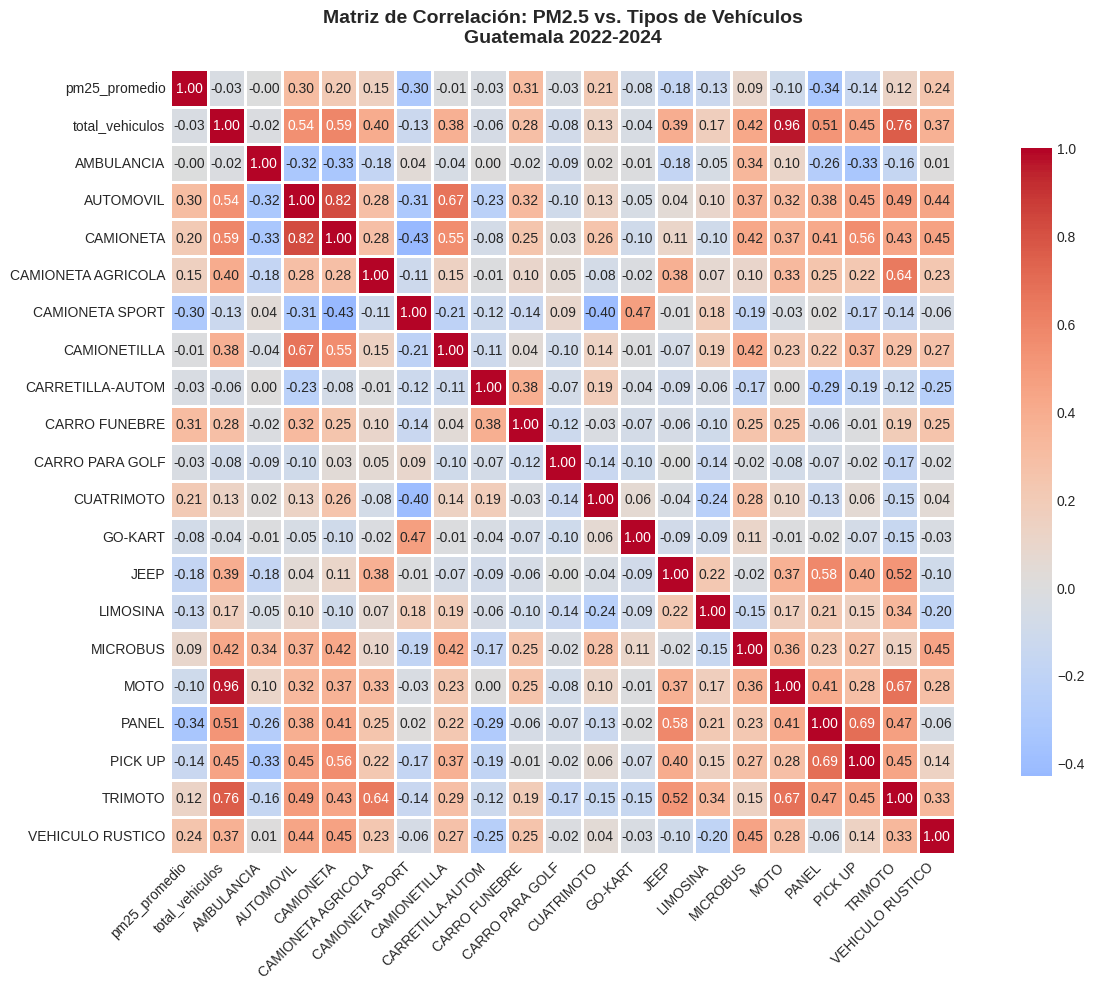

✓ Heatmap generado


In [16]:
# Visualización de matriz de correlación
if 'correlation_matrix' in locals():
    plt.figure(figsize=(14, 10))
    
    # Seleccionar solo las variables más relevantes para mejor visualización
    cols_viz = ['pm25_promedio', 'total_vehiculos'] + \
               [col for col in correlation_matrix.columns if col not in 
                ['pm25_promedio', 'total_vehiculos', 'pm25_std', 'pm25_min', 'pm25_max', 'n_mediciones']]
    
    corr_subset = correlation_matrix.loc[cols_viz, cols_viz]
    
    sns.heatmap(
        corr_subset,
        annot=True,
        fmt='.2f',
        cmap='coolwarm',
        center=0,
        square=True,
        linewidths=1,
        cbar_kws={"shrink": 0.8}
    )
    
    plt.title('Matriz de Correlación: PM2.5 vs. Tipos de Vehículos\nGuatemala 2022-2024', 
              fontsize=14, fontweight='bold', pad=20)
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()
    
    print("✓ Heatmap generado")

### 4.2 Regresión Lineal Simple: PM2.5 ~ Total Vehículos

In [17]:
# Regresión Lineal: PM2.5 = β₀ + β₁(Total_Vehículos) + ε
if 'df_merged_completo' in locals():
    print("[MODELO 1] Regresión Lineal Simple")
    print("Ecuación: PM2.5ₜ = β₀ + β₁(Vehículosₜ) + ε")
    print("="*80)
    
    # Preparar datos
    X = df_merged_completo[['total_vehiculos']].values
    y = df_merged_completo['pm25_promedio'].values
    
    # Entrenar modelo
    modelo_lr = LinearRegression()
    modelo_lr.fit(X, y)
    
    # Predicciones
    y_pred = modelo_lr.predict(X)
    
    # Coeficientes
    beta_0 = modelo_lr.intercept_
    beta_1 = modelo_lr.coef_[0]
    
    print(f"\nCoeficientes del modelo:")
    print(f"β₀ (Intercepto): {beta_0:.4f} μg/m³")
    print(f"β₁ (Pendiente):  {beta_1:.6f} μg/m³ por vehículo")
    
    print(f"\n📊 Interpretación:")
    print(f"Por cada 1,000 vehículos adicionales registrados, se espera un incremento")
    print(f"de {beta_1 * 1000:.4f} μg/m³ en la concentración promedio mensual de PM2.5.")
    
    # Métricas de desempeño
    r2 = r2_score(y, y_pred)
    mae = mean_absolute_error(y, y_pred)
    rmse = np.sqrt(mean_squared_error(y, y_pred))
    
    print(f"\nMétricas de desempeño:")
    print(f"R² (coeficiente de determinación): {r2:.4f}")
    print(f"MAE (error absoluto medio):         {mae:.4f} μg/m³")
    print(f"RMSE (raíz del error cuadrático):   {rmse:.4f} μg/m³")
    
    # Test de significancia estadística
    from scipy.stats import pearsonr
    corr_coef, p_value = pearsonr(X.flatten(), y)
    
    print(f"\nTest de significancia estadística:")
    print(f"Correlación de Pearson (r): {corr_coef:.4f}")
    print(f"P-value:                     {p_value:.6f}")
    
    if p_value < 0.05:
        print(f"✓ La correlación ES estadísticamente significativa (p < 0.05)")
        print(f"  Se rechaza H₀. Existe evidencia de relación lineal.")
    else:
        print(f"⚠ La correlación NO es estadísticamente significativa (p ≥ 0.05)")
        print(f"  No se puede rechazar H₀.")

[MODELO 1] Regresión Lineal Simple
Ecuación: PM2.5ₜ = β₀ + β₁(Vehículosₜ) + ε

Coeficientes del modelo:
β₀ (Intercepto): 37.2183 μg/m³
β₁ (Pendiente):  -0.000467 μg/m³ por vehículo

📊 Interpretación:
Por cada 1,000 vehículos adicionales registrados, se espera un incremento
de -0.4667 μg/m³ en la concentración promedio mensual de PM2.5.

Métricas de desempeño:
R² (coeficiente de determinación): 0.0009
MAE (error absoluto medio):         17.4822 μg/m³
RMSE (raíz del error cuadrático):   23.2724 μg/m³

Test de significancia estadística:
Correlación de Pearson (r): -0.0306
P-value:                     0.863455
⚠ La correlación NO es estadísticamente significativa (p ≥ 0.05)
  No se puede rechazar H₀.


### 4.3 Regresión Lineal Múltiple: PM2.5 ~ Tipos de Vehículos + Estacionalidad

In [18]:
# Regresión Lineal Múltiple incluyendo tipos de vehículos y estacionalidad
if 'df_merged_completo' in locals():
    print("[MODELO 2] Regresión Lineal Múltiple")
    print("Variables: Tipos de vehículos + Época seca")
    print("="*80)
    
    # Preparar features
    # Seleccionar columnas de tipos de vehículos (excluir total_vehiculos para evitar multicolinealidad)
    cols_tipos = [col for col in df_merged_completo.columns 
                  if col not in ['pm25_promedio', 'total_vehiculos', 'anio_mes', 'fecha_pm25', 
                                'fecha_vehiculos', 'anio', 'mes', 'trimestre', 'pm25_std', 
                                'pm25_min', 'pm25_max', 'n_mediciones', 'epoca_seca']
                  and df_merged_completo[col].dtype in [np.number]]
    
    # Añadir variable dummy de época seca
    X_multi = df_merged_completo[cols_tipos + ['epoca_seca']].copy()
    X_multi['epoca_seca'] = X_multi['epoca_seca'].astype(int)
    
    y_multi = df_merged_completo['pm25_promedio'].values
    
    # Entrenar modelo
    modelo_mlr = LinearRegression()
    modelo_mlr.fit(X_multi, y_multi)
    
    # Predicciones
    y_pred_multi = modelo_mlr.predict(X_multi)
    
    # Coeficientes
    coeficientes = pd.DataFrame({
        'Variable': X_multi.columns,
        'Coeficiente': modelo_mlr.coef_
    }).sort_values('Coeficiente', key=abs, ascending=False)
    
    print(f"\nCoeficientes del modelo (ordenados por magnitud):")
    print(f"Intercepto: {modelo_mlr.intercept_:.4f}\n")
    display(coeficientes)
    
    # Métricas
    r2_multi = r2_score(y_multi, y_pred_multi)
    mae_multi = mean_absolute_error(y_multi, y_pred_multi)
    rmse_multi = np.sqrt(mean_squared_error(y_multi, y_pred_multi))
    
    print(f"\nMétricas de desempeño:")
    print(f"R²:   {r2_multi:.4f}")
    print(f"MAE:  {mae_multi:.4f} μg/m³")
    print(f"RMSE: {rmse_multi:.4f} μg/m³")
    
    print(f"\n📊 Comparación con modelo simple:")
    print(f"Mejora en R²: {(r2_multi - r2):.4f} ({(r2_multi - r2)/r2*100:.2f}%)")

[MODELO 2] Regresión Lineal Múltiple
Variables: Tipos de vehículos + Época seca

Coeficientes del modelo (ordenados por magnitud):
Intercepto: 19.9282



,Variable,Coeficiente
0,epoca_seca,22.85



Métricas de desempeño:
R²:   0.2374
MAE:  14.9396 μg/m³
RMSE: 20.3321 μg/m³

📊 Comparación con modelo simple:
Mejora en R²: 0.2365 (25203.39%)


### 4.4 Random Forest (Opcional): Importancia de Variables

[MODELO 3] Random Forest Regressor
Objetivo: Identificar qué tipo/marca de vehículo tiene mayor impacto

Métricas en conjunto de entrenamiento:
R²:   0.2522
RMSE: 16.6733 μg/m³

Métricas en conjunto de prueba:
R²:   -0.0900
RMSE: 31.6977 μg/m³

Importancia de variables (top 10):


,Variable,Importancia
0,epoca_seca,1.00


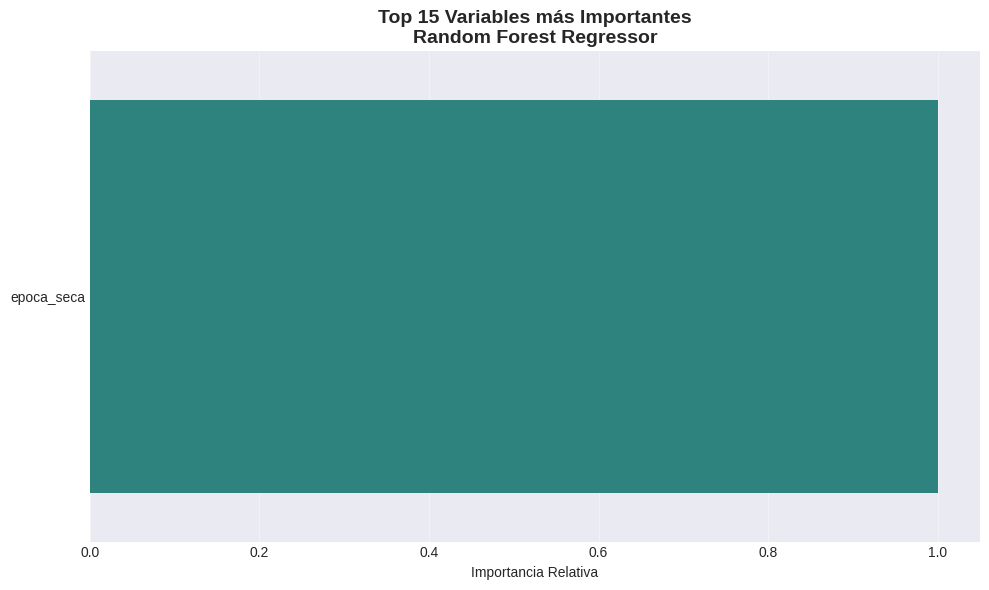

In [19]:
# Random Forest para identificar importancia de variables
if 'df_merged_completo' in locals():
    print("[MODELO 3] Random Forest Regressor")
    print("Objetivo: Identificar qué tipo/marca de vehículo tiene mayor impacto")
    print("="*80)
    
    # Usar las mismas features que en regresión múltiple
    X_rf = X_multi.copy()
    y_rf = y_multi.copy()
    
    # Split train/test (80/20)
    X_train, X_test, y_train, y_test = train_test_split(
        X_rf, y_rf, test_size=0.2, random_state=42
    )
    
    # Entrenar Random Forest
    modelo_rf = RandomForestRegressor(
        n_estimators=100,
        max_depth=10,
        random_state=42,
        n_jobs=-1
    )
    
    modelo_rf.fit(X_train, y_train)
    
    # Predicciones
    y_pred_train = modelo_rf.predict(X_train)
    y_pred_test = modelo_rf.predict(X_test)
    
    # Métricas
    print("\nMétricas en conjunto de entrenamiento:")
    print(f"R²:   {r2_score(y_train, y_pred_train):.4f}")
    print(f"RMSE: {np.sqrt(mean_squared_error(y_train, y_pred_train)):.4f} μg/m³")
    
    print("\nMétricas en conjunto de prueba:")
    print(f"R²:   {r2_score(y_test, y_pred_test):.4f}")
    print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_test)):.4f} μg/m³")
    
    # Importancia de features
    feature_importance = pd.DataFrame({
        'Variable': X_rf.columns,
        'Importancia': modelo_rf.feature_importances_
    }).sort_values('Importancia', ascending=False)
    
    print("\nImportancia de variables (top 10):")
    display(feature_importance.head(10))
    
    # Visualización
    plt.figure(figsize=(10, 6))
    top_n = 15
    sns.barplot(
        data=feature_importance.head(top_n),
        x='Importancia',
        y='Variable',
        palette='viridis'
    )
    plt.title(f'Top {top_n} Variables más Importantes\nRandom Forest Regressor',
              fontsize=14, fontweight='bold')
    plt.xlabel('Importancia Relativa')
    plt.ylabel('')
    plt.tight_layout()
    plt.show()

---
## Fase 5: Evaluación y Visualización (Evaluation)

### 5.1 Time Series Dual: Vehículos vs. PM2.5

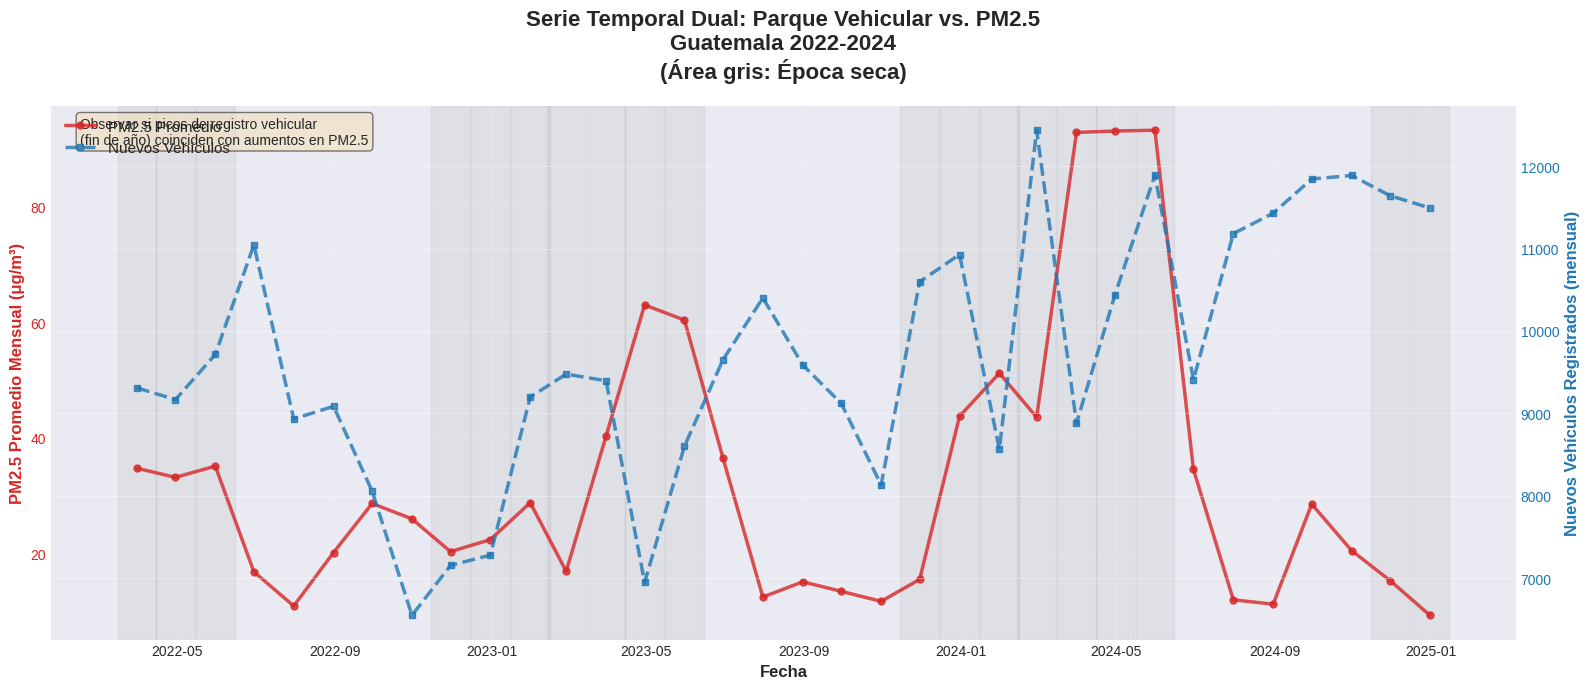

✓ Gráfico de serie temporal generado


In [20]:
# Gráfico de doble eje: Vehículos vs PM2.5 en el tiempo
if 'df_merged_completo' in locals():
    fig, ax1 = plt.subplots(figsize=(16, 7))
    
    # Eje principal: PM2.5
    color_pm25 = 'tab:red'
    ax1.set_xlabel('Fecha', fontsize=12, fontweight='bold')
    ax1.set_ylabel('PM2.5 Promedio Mensual (μg/m³)', 
                   color=color_pm25, fontsize=12, fontweight='bold')
    
    line1 = ax1.plot(df_merged_completo['fecha_pm25'], 
                     df_merged_completo['pm25_promedio'],
                     color=color_pm25, linewidth=2.5, marker='o', markersize=5,
                     label='PM2.5 Promedio', alpha=0.8)
    
    ax1.tick_params(axis='y', labelcolor=color_pm25)
    ax1.grid(True, alpha=0.3)
    
    # Marcar época seca con fondo gris
    for idx, row in df_merged_completo.iterrows():
        if row['epoca_seca']:
            ax1.axvspan(row['fecha_pm25'] - pd.DateOffset(days=15), 
                       row['fecha_pm25'] + pd.DateOffset(days=15),
                       alpha=0.1, color='gray')
    
    # Eje secundario: Vehículos
    ax2 = ax1.twinx()
    color_vehiculos = 'tab:blue'
    ax2.set_ylabel('Nuevos Vehículos Registrados (mensual)', 
                   color=color_vehiculos, fontsize=12, fontweight='bold')
    
    line2 = ax2.plot(df_merged_completo['fecha_pm25'], 
                     df_merged_completo['total_vehiculos'],
                     color=color_vehiculos, linewidth=2.5, marker='s', markersize=5,
                     label='Nuevos Vehículos', alpha=0.8, linestyle='--')
    
    ax2.tick_params(axis='y', labelcolor=color_vehiculos)
    
    # Título y leyenda
    plt.title('Serie Temporal Dual: Parque Vehicular vs. PM2.5\nGuatemala 2022-2024\n(Área gris: Época seca)', 
              fontsize=16, fontweight='bold', pad=20)
    
    # Combinar leyendas
    lines = line1 + line2
    labels = [l.get_label() for l in lines]
    ax1.legend(lines, labels, loc='upper left', fontsize=11, framealpha=0.9)
    
    # Anotación de interpretación
    ax1.text(0.02, 0.98, 
             'Observar si picos de registro vehicular\n(fin de año) coinciden con aumentos en PM2.5',
             transform=ax1.transAxes,
             fontsize=10, verticalalignment='top',
             bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    
    plt.tight_layout()
    plt.show()
    
    print("✓ Gráfico de serie temporal generado")

### 5.2 Scatter Plot con Línea de Regresión

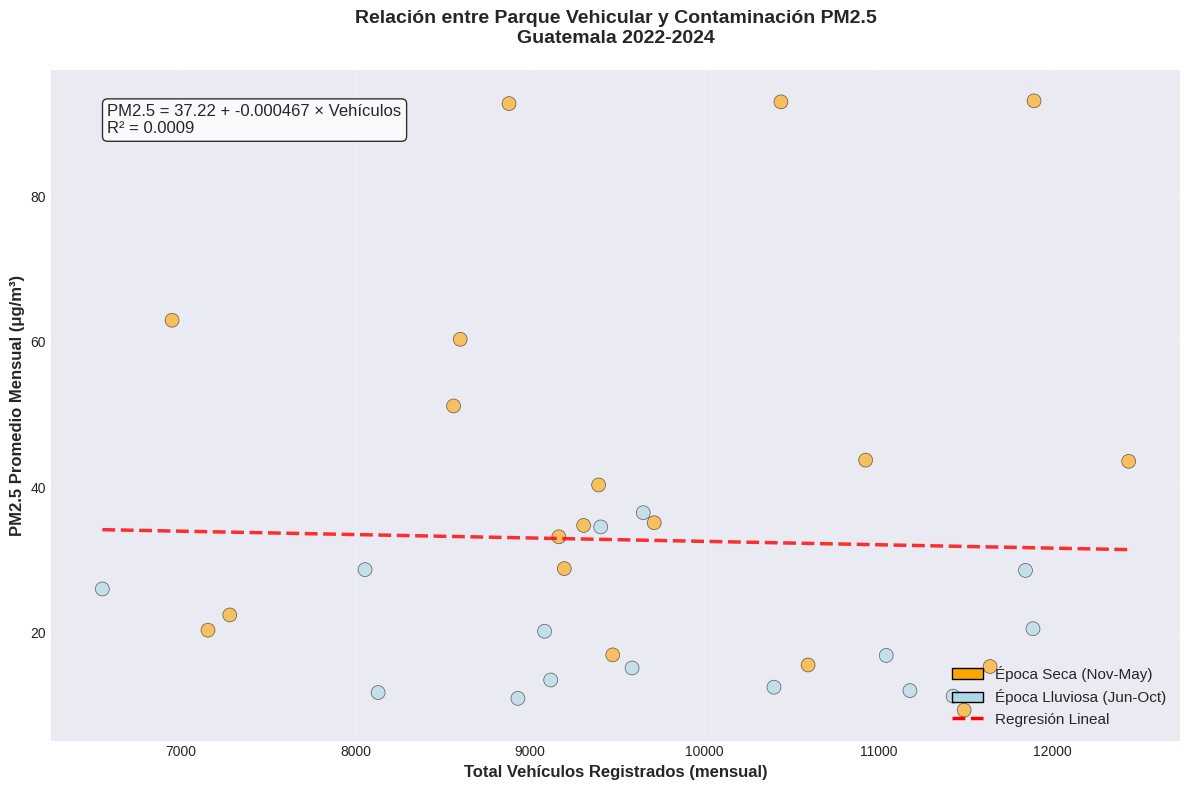

✓ Scatter plot con regresión generado


In [21]:
# Scatter plot con línea de tendencia
if 'df_merged_completo' in locals() and 'modelo_lr' in locals():
    fig, ax = plt.subplots(figsize=(12, 8))
    
    # Scatter plot con colores por época
    colores = df_merged_completo['epoca_seca'].map({True: 'orange', False: 'lightblue'})
    
    ax.scatter(df_merged_completo['total_vehiculos'], 
               df_merged_completo['pm25_promedio'],
               c=colores, s=100, alpha=0.6, edgecolors='black', linewidth=0.5)
    
    # Línea de regresión
    x_line = np.linspace(df_merged_completo['total_vehiculos'].min(),
                         df_merged_completo['total_vehiculos'].max(), 100)
    y_line = modelo_lr.predict(x_line.reshape(-1, 1))
    
    ax.plot(x_line, y_line, 'r--', linewidth=2.5, label='Línea de Regresión', alpha=0.8)
    
    # Ecuación de regresión en el gráfico
    ecuacion = f'PM2.5 = {beta_0:.2f} + {beta_1:.6f} × Vehículos'
    r2_text = f'R² = {r2:.4f}'
    
    ax.text(0.05, 0.95, f'{ecuacion}\n{r2_text}',
            transform=ax.transAxes,
            fontsize=12, verticalalignment='top',
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
    
    # Leyenda de colores
    from matplotlib.patches import Patch
    legend_elements = [
        Patch(facecolor='orange', edgecolor='black', label='Época Seca (Nov-May)'),
        Patch(facecolor='lightblue', edgecolor='black', label='Época Lluviosa (Jun-Oct)'),
        plt.Line2D([0], [0], color='r', linewidth=2.5, linestyle='--', label='Regresión Lineal')
    ]
    ax.legend(handles=legend_elements, loc='lower right', fontsize=11)
    
    ax.set_xlabel('Total Vehículos Registrados (mensual)', fontsize=12, fontweight='bold')
    ax.set_ylabel('PM2.5 Promedio Mensual (μg/m³)', fontsize=12, fontweight='bold')
    ax.set_title('Relación entre Parque Vehicular y Contaminación PM2.5\nGuatemala 2022-2024',
                fontsize=14, fontweight='bold', pad=20)
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    print("✓ Scatter plot con regresión generado")

### 5.3 Análisis por Tipo de Vehículo

In [22]:
# Debug detallado
print("=== DIAGNÓSTICO COMPLETO ===\n")

print("1. Todas las columnas:")
print(df_merged_completo.columns.tolist())

print("\n2. Columnas numéricas:")
cols_numericas = [col for col in df_merged_completo.columns
                  if df_merged_completo[col].dtype in [np.number]]
print(cols_numericas)

print("\n3. Columnas a excluir:")
columnas_excluir = {
    'pm25_promedio', 'pm25_std', 'pm25_min', 'pm25_max', 'n_mediciones',
    'total_vehiculos', 'anio_mes', 'fecha_pm25', 'fecha_vehiculos',
    'anio', 'mes', 'trimestre', 'epoca_seca', 'fecha'
}
print(columnas_excluir)

print("\n4. Columnas numéricas NO excluidas:")
tipos_vehiculos = [col for col in cols_numericas if col not in columnas_excluir]
print(tipos_vehiculos)

print("\n5. Verificar suma de cada tipo:")
for tipo in tipos_vehiculos:
    suma = df_merged_completo[tipo].sum()
    print(f"  {tipo}: {suma}")

=== DIAGNÓSTICO COMPLETO ===

1. Todas las columnas:
['fecha_pm25', 'pm25_promedio', 'pm25_std', 'pm25_min', 'pm25_max', 'n_mediciones', 'anio_mes', 'total_vehiculos', 'fecha_vehiculos', 'AMBULANCIA', 'AUTOMOVIL', 'CAMIONETA', 'CAMIONETA AGRICOLA', 'CAMIONETA SPORT', 'CAMIONETILLA', 'CARRETILLA-AUTOM', 'CARRO FUNEBRE', 'CARRO PARA GOLF', 'CUATRIMOTO', 'GO-KART', 'JEEP', 'LIMOSINA', 'MICROBUS', 'MOTO', 'PANEL', 'PICK UP', 'TRIMOTO', 'VEHICULO RUSTICO', 'anio', 'mes', 'trimestre', 'epoca_seca']

2. Columnas numéricas:
[]

3. Columnas a excluir:
{'pm25_max', 'pm25_promedio', 'n_mediciones', 'anio', 'anio_mes', 'epoca_seca', 'pm25_std', 'fecha', 'pm25_min', 'total_vehiculos', 'fecha_vehiculos', 'trimestre', 'fecha_pm25', 'mes'}

4. Columnas numéricas NO excluidas:
[]

5. Verificar suma de cada tipo:


In [23]:
# ¿Cuántos meses tienes de 2024?
print("Meses por año:")
for year in [2022, 2023, 2024]:
    meses = df_merged_completo[df_merged_completo['anio'] == year]['mes'].unique()
    print(f"{year}: {sorted(meses)} ({len(meses)} meses)")

Meses por año:
2022: [np.int32(3), np.int32(4), np.int32(5), np.int32(6), np.int32(7), np.int32(8), np.int32(9), np.int32(10), np.int32(11), np.int32(12)] (10 meses)
2023: [np.int32(1), np.int32(2), np.int32(3), np.int32(4), np.int32(5), np.int32(6), np.int32(7), np.int32(8), np.int32(9), np.int32(10), np.int32(11), np.int32(12)] (12 meses)
2024: [np.int32(1), np.int32(2), np.int32(3), np.int32(4), np.int32(5), np.int32(6), np.int32(7), np.int32(8), np.int32(9), np.int32(10), np.int32(11), np.int32(12)] (12 meses)


Tipos de vehículos encontrados: 19
Columnas: ['AMBULANCIA', 'AUTOMOVIL', 'CAMIONETA', 'CAMIONETA AGRICOLA', 'CAMIONETA SPORT', 'CAMIONETILLA', 'CARRETILLA-AUTOM', 'CARRO FUNEBRE', 'CARRO PARA GOLF', 'CUATRIMOTO', 'GO-KART', 'JEEP', 'LIMOSINA', 'MICROBUS', 'MOTO', 'PANEL', 'PICK UP', 'TRIMOTO', 'VEHICULO RUSTICO']

Correlaciones PM2.5 vs. Tipos de Vehículos:


,correlacion,p_value
PANEL,-0.34,0.05
CARRO FUNEBRE,0.31,0.07
CAMIONETA SPORT,-0.30,0.08
AUTOMOVIL,0.30,0.09
VEHICULO RUSTICO,0.24,0.16
CUATRIMOTO,0.21,0.24
CAMIONETA,0.20,0.25
JEEP,-0.18,0.32
CAMIONETA AGRICOLA,0.15,0.39
PICK UP,-0.14,0.43


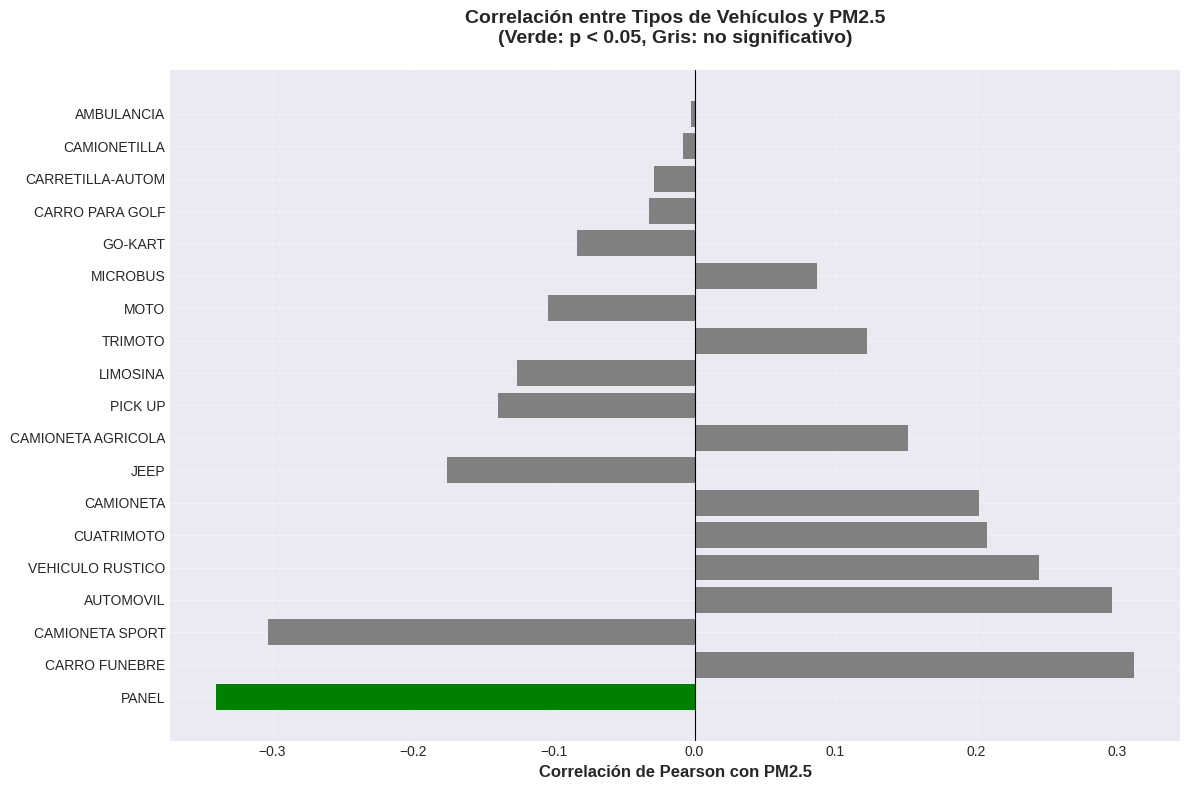


✓ Análisis por tipo de vehículo completado


In [24]:
# Comparación de correlaciones por tipo de vehículo
if 'df_merged_completo' in locals():
    # Definir columnas a excluir
    columnas_excluir = {
        'pm25_promedio', 'pm25_std', 'pm25_min', 'pm25_max', 'n_mediciones',
        'total_vehiculos', 'anio_mes', 'fecha_pm25', 'fecha_vehiculos',
        'anio', 'mes', 'trimestre', 'epoca_seca', 'fecha'
    }

    # Usar select_dtypes en lugar de dtype check manual
    cols_numericas = df_merged_completo.select_dtypes(include=[np.number]).columns.tolist()

    # Filtrar columnas excluidas
    tipos_vehiculos = [col for col in cols_numericas if col not in columnas_excluir]

    print(f"Tipos de vehículos encontrados: {len(tipos_vehiculos)}")
    print(f"Columnas: {tipos_vehiculos}\n")

    # Calcular correlación de cada tipo con PM2.5
    correlaciones_tipos = {}
    for tipo in tipos_vehiculos:
        if df_merged_completo[tipo].sum() > 0:  # Solo si hay datos
            corr, p_val = pearsonr(df_merged_completo[tipo],
                                   df_merged_completo['pm25_promedio'])
            correlaciones_tipos[tipo] = {'correlacion': corr, 'p_value': p_val}

    if len(correlaciones_tipos) == 0:
        print("⚠ Todas las columnas de tipos de vehículos tienen suma = 0")
    else:
        # Crear DataFrame y ordenar
        df_corr_tipos = pd.DataFrame(correlaciones_tipos).T.sort_values('correlacion',
                                                                         key=abs,
                                                                         ascending=False)

        print("Correlaciones PM2.5 vs. Tipos de Vehículos:")
        print("="*80)
        display(df_corr_tipos)

        # Visualización
        plt.figure(figsize=(12, 8))

        # Colores según significancia estadística
        colores_barras = ['green' if p < 0.05 else 'gray'
                          for p in df_corr_tipos['p_value']]

        plt.barh(df_corr_tipos.index, df_corr_tipos['correlacion'], color=colores_barras)
        plt.xlabel('Correlación de Pearson con PM2.5', fontsize=12, fontweight='bold')
        plt.ylabel('')
        plt.title('Correlación entre Tipos de Vehículos y PM2.5\n(Verde: p < 0.05, Gris: no significativo)',
                  fontsize=14, fontweight='bold', pad=20)
        plt.axvline(x=0, color='black', linestyle='-', linewidth=0.8)
        plt.grid(axis='x', alpha=0.3)
        plt.tight_layout()
        plt.show()

        print("\n✓ Análisis por tipo de vehículo completado")

### 5.4 Análisis de Residuos

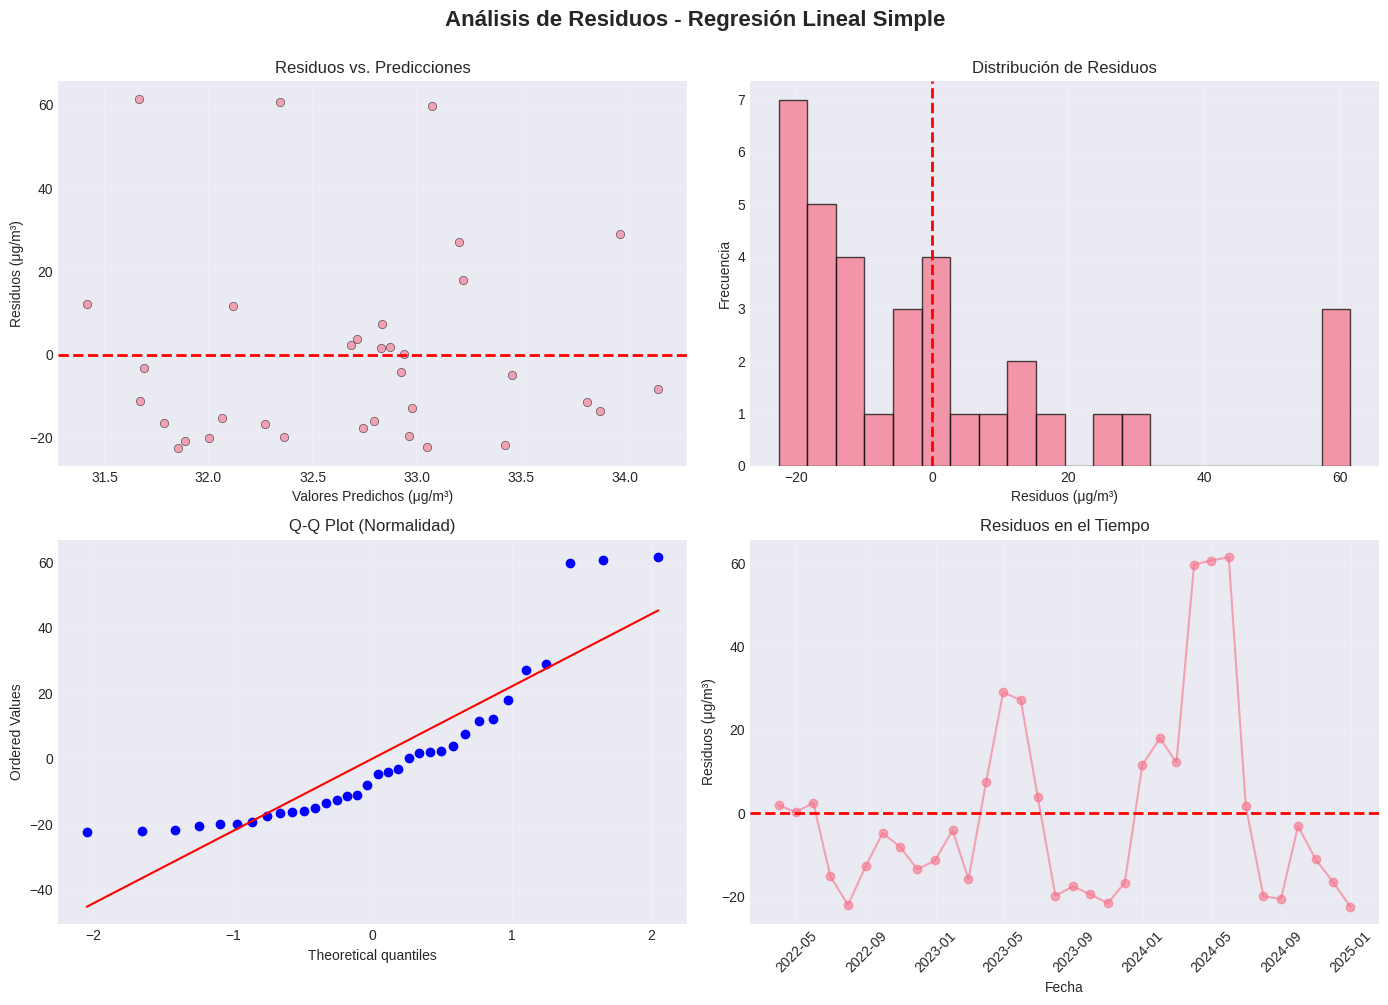


Test de Shapiro-Wilk (Normalidad de Residuos):
Estadístico: 0.8085
P-value: 0.0000
⚠ Los residuos NO siguen una distribución normal (p ≤ 0.05)

✓ Análisis de residuos completado


In [25]:
# Análisis de residuos del modelo de regresión lineal simple
if 'modelo_lr' in locals() and 'df_merged_completo' in locals():
    # Calcular residuos
    residuos = y - y_pred
    
    # Crear figura con subplots
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    
    # 1. Residuos vs. Valores predichos
    axes[0, 0].scatter(y_pred, residuos, alpha=0.6, edgecolors='black', linewidth=0.5)
    axes[0, 0].axhline(y=0, color='r', linestyle='--', linewidth=2)
    axes[0, 0].set_xlabel('Valores Predichos (μg/m³)')
    axes[0, 0].set_ylabel('Residuos (μg/m³)')
    axes[0, 0].set_title('Residuos vs. Predicciones')
    axes[0, 0].grid(True, alpha=0.3)
    
    # 2. Distribución de residuos (histograma)
    axes[0, 1].hist(residuos, bins=20, edgecolor='black', alpha=0.7)
    axes[0, 1].axvline(x=0, color='r', linestyle='--', linewidth=2)
    axes[0, 1].set_xlabel('Residuos (μg/m³)')
    axes[0, 1].set_ylabel('Frecuencia')
    axes[0, 1].set_title('Distribución de Residuos')
    axes[0, 1].grid(True, alpha=0.3)
    
    # 3. Q-Q Plot (normalidad)
    stats.probplot(residuos, dist="norm", plot=axes[1, 0])
    axes[1, 0].set_title('Q-Q Plot (Normalidad)')
    axes[1, 0].grid(True, alpha=0.3)
    
    # 4. Residuos vs. Tiempo (detectar patrones temporales)
    axes[1, 1].plot(df_merged_completo['fecha_pm25'], residuos, 
                    marker='o', linestyle='-', alpha=0.6)
    axes[1, 1].axhline(y=0, color='r', linestyle='--', linewidth=2)
    axes[1, 1].set_xlabel('Fecha')
    axes[1, 1].set_ylabel('Residuos (μg/m³)')
    axes[1, 1].set_title('Residuos en el Tiempo')
    axes[1, 1].grid(True, alpha=0.3)
    axes[1, 1].tick_params(axis='x', rotation=45)
    
    plt.suptitle('Análisis de Residuos - Regresión Lineal Simple', 
                fontsize=16, fontweight='bold', y=1.00)
    plt.tight_layout()
    plt.show()
    
    # Test de normalidad (Shapiro-Wilk)
    stat, p_normalidad = stats.shapiro(residuos)
    print(f"\nTest de Shapiro-Wilk (Normalidad de Residuos):")
    print(f"Estadístico: {stat:.4f}")
    print(f"P-value: {p_normalidad:.4f}")
    
    if p_normalidad > 0.05:
        print("✓ Los residuos siguen una distribución normal (p > 0.05)")
    else:
        print("⚠ Los residuos NO siguen una distribución normal (p ≤ 0.05)")
    
    print("\n✓ Análisis de residuos completado")

---
## Interpretación de Resultados y Conclusiones

### Resumen Ejecutivo

In [26]:
# Generar resumen ejecutivo automático
if all(var in locals() for var in ['beta_1', 'r2', 'p_value', 'corr_coef']):
    print("="*80)
    print("RESUMEN EJECUTIVO - ANÁLISIS PM2.5 vs. PARQUE VEHICULAR")
    print("Guatemala 2022-2024 | Metodología CRISP-DM")
    print("="*80)
    
    print("\n[1] HALLAZGOS PRINCIPALES")
    print(f"    • Correlación de Pearson: r = {corr_coef:.4f}")
    print(f"    • Significancia estadística: p = {p_value:.6f}")
    print(f"    • Coeficiente de determinación: R² = {r2:.4f}")
    print(f"    • Impacto marginal: {beta_1*1000:.4f} μg/m³ por cada 1,000 vehículos")
    
    print("\n[2] INTERPRETACIÓN")
    if p_value < 0.05:
        print("    ✓ Existe evidencia estadísticamente significativa de correlación")
        if r2 > 0.5:
            print(f"    ✓ El modelo explica el {r2*100:.1f}% de la variabilidad en PM2.5")
        else:
            print(f"    ⚠ El modelo explica solo el {r2*100:.1f}% de la variabilidad")
            print("      Otros factores (meteorología, industria, etc.) son relevantes")
    else:
        print("    ⚠ No se encontró correlación estadísticamente significativa")
    
    print("\n[3] CONSIDERACIONES METODOLÓGICAS")
    print("    • Los datos de vehículos son de 'Alza' (registros nuevos)")
    print("    • El análisis mide el impacto marginal incremental")
    print("    • La estacionalidad (época seca) debe considerarse como confusor")
    
    print("\n[4] LIMITACIONES")
    print("    • No se incluyen variables meteorológicas (temperatura, viento, humedad)")
    print("    • No se consideran otras fuentes de PM2.5 (industria, quema de biomasa)")
    print("    • Los datos de PM2.5 pueden tener ruido de medición")
    print("    • El parque vehicular total ≠ suma de registros nuevos")
    
    print("\n[5] RECOMENDACIONES")
    print("    1. Incorporar variables meteorológicas para modelo más robusto")
    print("    2. Analizar separadamente por tipo de vehículo (motos vs. autos)")
    print("    3. Considerar análisis de series temporales (ARIMA, SARIMA)")
    print("    4. Incluir datos de otros contaminantes (NO2, CO) para contexto")
    print("    5. Realizar análisis de causalidad (Granger, VAR)")
    
    print("\n" + "="*80)

---
## Exportación de Resultados

In [27]:
# Exportar dataset procesado y resultados
if 'df_merged_completo' in locals():
    # Guardar dataset procesado
    df_merged_completo.to_csv('datos_procesados_pm25_vehiculos.csv', index=False)
    print("✓ Dataset procesado guardado: datos_procesados_pm25_vehiculos.csv")
    
    # Guardar resultados de modelos
    resultados = {
        'modelo': ['Regresión Lineal Simple', 'Regresión Lineal Múltiple', 'Random Forest'],
        'R2': [r2 if 'r2' in locals() else None,
               r2_multi if 'r2_multi' in locals() else None,
               r2_score(y_test, y_pred_test) if 'y_pred_test' in locals() else None],
        'RMSE': [rmse if 'rmse' in locals() else None,
                 rmse_multi if 'rmse_multi' in locals() else None,
                 np.sqrt(mean_squared_error(y_test, y_pred_test)) if 'y_pred_test' in locals() else None]
    }
    
    df_resultados = pd.DataFrame(resultados)
    df_resultados.to_csv('resultados_modelos.csv', index=False)
    print("✓ Resultados de modelos guardados: resultados_modelos.csv")
    
    print("\n✅ ANÁLISIS COMPLETADO EXITOSAMENTE")

✓ Dataset procesado guardado: datos_procesados_pm25_vehiculos.csv
✓ Resultados de modelos guardados: resultados_modelos.csv

✅ ANÁLISIS COMPLETADO EXITOSAMENTE


---
## Notas Finales

### Contexto Académico (Maestría)

**Puntos clave para defensa/presentación:**

1. **Sincronización Temporal**: El mayor reto fue la agregación de datos de alta frecuencia (5 min) a granularidad mensual sin perder información crítica.

2. **Estacionalidad**: En Guatemala, el PM2.5 aumenta en época seca (nov-may) independientemente del parque vehicular. Esto puede actuar como confusor.

3. **Impacto Marginal vs. Total**: Los datos del INE son de "Alza" (nuevos registros), por lo que el análisis mide el **impacto marginal incremental**, no el efecto del parque total.

4. **Picos de Importación**: Los registros vehiculares típicamente aumentan a fin de año. Verificar si estos picos coinciden con aumentos en PM2.5 ayuda a establecer causalidad.

5. **Limitaciones del Modelo**: Un R² moderado (30-50%) no invalida el hallazgo. PM2.5 es multifactorial (meteorología, industria, geografía). El objetivo es cuantificar la **contribución vehicular**, no explicar toda la varianza.

### Próximos Pasos Sugeridos

- Incorporar datos meteorológicos (INSIVUMEH)
- Análisis de causalidad de Granger
- Modelos SARIMA para capturar estacionalidad
- Validación cruzada con datos de otras estaciones de monitoreo
- Análisis geoespacial (si hay múltiples estaciones)